# Orekit propagation tutorial w/ orbital perturbations

This jupyter notebook is a tool to help you use a high fidelity propagator. These instructions below will ensure you have the right setup.

- To download and install orekit and other dependencies, follow the instructions provided here: https://github.com/ARCLab-MIT/STORM-AI-devkit-2025/tree/main/orbit_propagator. 
    - NOTE: my orekit version is 11. The link has version 12. Pay attention that some functions might have a different name b/w the two versions.
- Ensure that orekit-data.zip is in the same directory as this file. If not, download it using pip install git+https://gitlab.orekit.org/orekit/orekit-data.git in the miniconda environment. The orekit-data.zip can also be found in the same link above.
- Ensure that orekit-data.zip contains a Space-Weather-Data folder. In it, there should be SOLFSMY.TXT and DTCFILE.TXT. These files are used by the JB2008 atmospheric model. 
    - REMEMBER to download the latest .txt files and replace them inside the orekit-data.zip. You will need the latest ones if you want to run simulation w/ starting epoch equal to the current date. You can find the latest .txt files here: https://spacewx.com/jb2008/.

Now you are equipped to use the propagator.

In [3]:
import pkg_resources
print(pkg_resources.get_distribution("orekit").version)

13.1


In [5]:
# Libraries

# Initialize orekit and JVM
import orekit
vm = orekit.initVM()

from orekit.pyhelpers import setup_orekit_curdir, absolutedate_to_datetime
setup_orekit_curdir()

from org.orekit.orbits import KeplerianOrbit, EquinoctialOrbit, PositionAngleType, OrbitType, CartesianOrbit
from org.orekit.frames import FramesFactory, LOFType, Frame
from org.orekit.time import AbsoluteDate, TimeScalesFactory
from org.orekit.utils import Constants, PVCoordinates, TimeStampedPVCoordinates, AbsolutePVCoordinates
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.bodies import OneAxisEllipsoid, CelestialBodyFactory, CelestialBody
from org.orekit.utils import IERSConventions
from orekit import JArray_double, JArray
from java.util import ArrayList
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.propagation.conversion import NumericalPropagatorBuilder, DormandPrince853IntegratorBuilder, DormandPrince54IntegratorBuilder, OsculatingToMeanElementsConverter, ClassicalRungeKuttaIntegratorBuilder

from org.orekit.forces import ForceModel
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction, OceanTides, SolidTides
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient, RadiationSensitive
from org.orekit.models.earth.atmosphere.data import CssiSpaceWeatherData, JB2008SpaceEnvironmentData
from org.orekit.forces.drag import IsotropicDrag, DragForce
from org.orekit.models.earth.atmosphere import DTM2000, JB2008, Atmosphere

from math import radians, degrees, pi
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import matplotlib.ticker as ticker

plt.rcParams.update({'font.size': 12})


File or folder: /Users/beaveracosta/Desktop/16.346/orekit-data.zip  not found


            The Orekit library relies on some external data for physical models.
            Typical data are the Earth Orientation Parameters and the leap seconds history,
            both being provided by the IERS or the planetary ephemerides provided by JPL.
            Such data is stored in text or binary files with specific formats that Orekit knows
            how to read, and needs to be provided for the library to work.

            You can download a starting file with this data from the orekit gitlab at:
            https://gitlab.orekit.org/orekit/orekit-data

            or by the function:
            orekit.pyhelpers.download_orekit_data_curdir()

            


In [46]:
# Functions

def prop_orbit(initial_orbit, duration, step, sel_gravity_force, degree, torder):

    initialDate = initial_orbit.getDate()
    tspan = [initialDate.shiftedBy(float(dt)) for dt in np.linspace(0, duration, int(duration / step))]
    
    mass = 100.0 # kg - default mass in orekit is 1000 kg
    
    # =============================================================================
    #% Propagator setup
    # =============================================================================
    
    orbitType = initialOrbit.getType()
    initialState = SpacecraftState(initialOrbit, mass)
    minStep = 1e-6
    maxstep = 1.0e4
    initStep = 0.1
    positionTolerance = 1e-3
    tol = NumericalPropagator.tolerances(positionTolerance, initialOrbit, orbitType)
    integrator = DormandPrince853Integrator(minStep, maxstep, 
    JArray_double.cast_(tol[0]),  # Double array of doubles needs to be casted in Python
    JArray_double.cast_(tol[1]))
    integrator.setInitialStepSize(initStep)
    propagator_num = NumericalPropagator(integrator)
    propagator_num.setOrbitType(orbitType)
    propagator_num.setInitialState(initialState)

    gravityProvider = GravityFieldFactory.getConstantNormalizedProvider(degree, torder)
    gravityForce = HolmesFeatherstoneAttractionModel(earth.getBodyFrame(), gravityProvider)
    if sel_gravity_force == 1:
        propagator_num.addForceModel(gravityForce)
        
    # Add Solar Radiation Pressure
    cr = 1.0
    srpArea = 1.0  # m^2
    crossSection = 1.0  # m^2
    dragCoeff = 2.2  
    sun = CelestialBodyFactory.getSun()
    moon = CelestialBodyFactory.getMoon()
    spacecraft = IsotropicRadiationSingleCoefficient(srpArea, cr)
    srpProvider = SolarRadiationPressure(sun, earth.getEquatorialRadius(), spacecraft)
    propagator_num.addForceModel(srpProvider)

    # Add Solid Tides
    solidTidesBodies = ArrayList().of_(CelestialBody)
    solidTidesBodies.add(sun)
    solidTidesBodies.add(moon)
    solidTidesBodies = solidTidesBodies.toArray()
    solidTides = SolidTides(earth.getBodyFrame(), 
                            gravityProvider.getAe(), gravityProvider.getMu(),
                            gravityProvider.getTideSystem(), 
                            IERSConventions.IERS_2010,
                            TimeScalesFactory.getUT1(IERSConventions.IERS_2010, True), 
                            solidTidesBodies)
    propagator_num.addForceModel(solidTides)

    # Add Third Body Attractions
    propagator_num.addForceModel(ThirdBodyAttraction(sun))
    propagator_num.addForceModel(ThirdBodyAttraction(moon)) 

    # Add Custom Drag Force
    satmodel = IsotropicDrag(crossSection, dragCoeff) # Cross sectional area and the drag coefficient
    cswl = JB2008SpaceEnvironmentData("SOLFSMY.TXT","DTCFILE.TXT") 
    atmosphere = JB2008(cswl, sun, earth)
    dragForce = DragForce(atmosphere, satmodel)
    propagator_num.addForceModel(dragForce)

    # =============================================================================
    #% Orbit propagation
    # =============================================================================
    
    states = [propagator_num.propagate(tt)  for tt in tspan]
    
    return states


In [3]:
# =============================================================================
#% Constants/Basics
# =============================================================================
r_Earth = Constants.IERS2010_EARTH_EQUATORIAL_RADIUS #m
itrf    = FramesFactory.getITRF(IERSConventions.IERS_2010, True) # International Terrestrial Reference Frame, earth fixed
inertialFrame = FramesFactory.getEME2000()
earth = OneAxisEllipsoid(r_Earth,
                         Constants.IERS2010_EARTH_FLATTENING,
                         itrf)
mu = Constants.IERS2010_EARTH_MU #m^3/s^2
utc = TimeScalesFactory.getUTC()

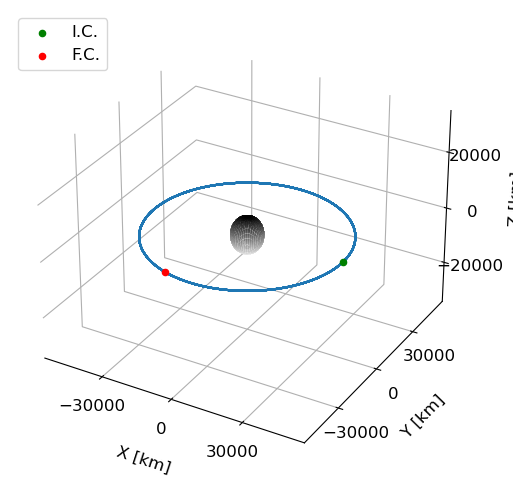

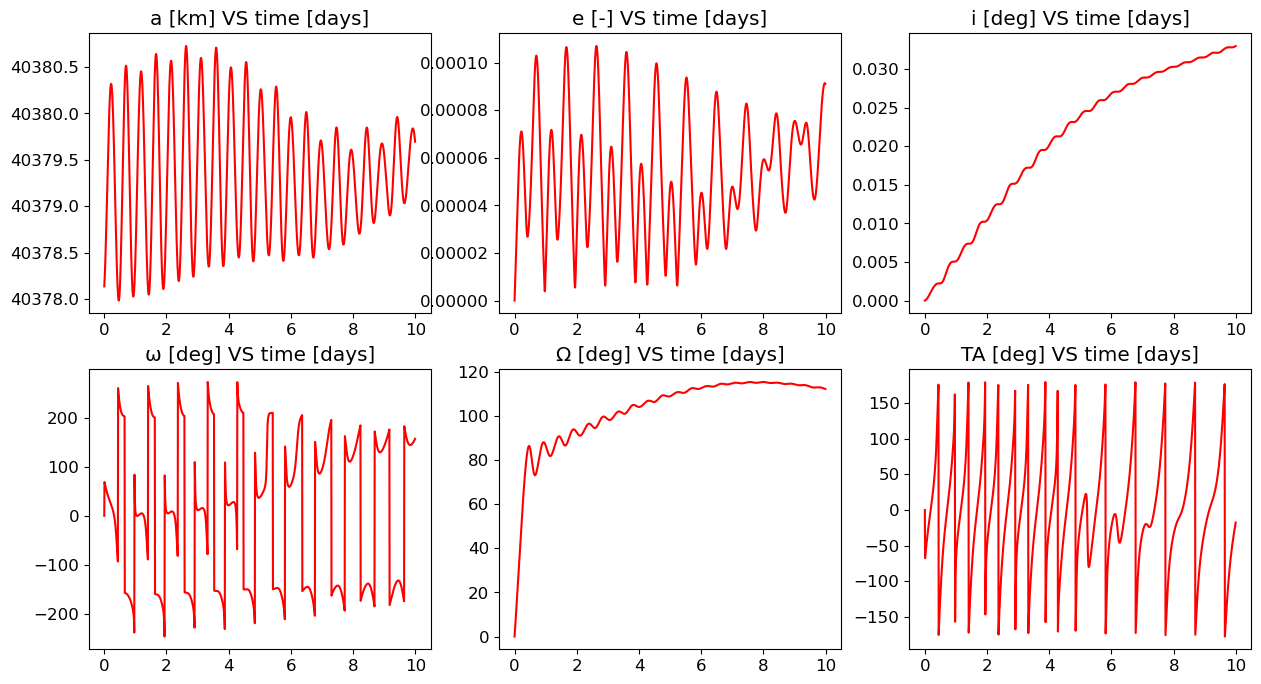

In [48]:
# =============================================================================
#% Orbit definition
# =============================================================================

deg = pi / 180

rp0 = r_Earth + 500 * 1e3 # perigee radius (m)
ra0 = r_Earth + 600 * 1e3 # apogee radius (m)

a0 = (rp0 + ra0) / 2 # semi-major axis (m)
e0 = (ra0 - rp0) / (ra0 + rp0) # eccentricity 
w0 = 0 * deg # perigee argument (rad)
i0 = 0 * deg # inclination (rad)
ra0 = 0 * deg # right ascension of ascending node (rad)
M0 = 0 * deg # anomaly

# Orbital perturbations
# Earth non spherical gravity field
degree = 2 # J2, J4
torder = 0 # J22, J42

initialDate = AbsoluteDate(2022, 1, 1, 0, 0, 00.000, utc) # date of orbit parameters
initialOrbit = KeplerianOrbit(a0, e0, i0, w0, ra0, M0, PositionAngle.TRUE, inertialFrame, initialDate, mu)
initialOrbit = EquinoctialOrbit(initialOrbit)

# duration = 10 * 86400.0 # 1 day in seconds
duration = initialOrbit.getKeplerianPeriod() # 1 orbital period in seconds

secs = 60.0
mins = 1
step = secs * mins # propagation step size [s]

sel_gravity_force = 1

# =============================================================================
#% Orbit propagation
# =============================================================================

states = prop_orbit(initialOrbit, duration, step, sel_gravity_force, degree, torder)
posvel = [state.getPVCoordinates() for state in states]
poss = [state.getPosition() for state in posvel]
vels = [state.getVelocity() for state in posvel]


# Calculating Keplerian Elements
kep_orbs = [KeplerianOrbit(state, inertialFrame, mu) for state in posvel] 
k_sma = [kep_orb.getA()*1e-3 for kep_orb in kep_orbs]
k_ecc = [kep_orb.getE() for kep_orb in kep_orbs]
k_incl = [kep_orb.getI() for kep_orb in kep_orbs]
k_omega = [kep_orb.getPerigeeArgument() for kep_orb in kep_orbs]
k_raan = [kep_orb.getRightAscensionOfAscendingNode() for kep_orb in kep_orbs]
k_trueanom = [kep_orb.getTrueAnomaly() for kep_orb in kep_orbs]

# =============================================================================
#% Plots
# =============================================================================

pp = [[pos.getX(), pos.getY(), pos.getZ()] for pos in poss]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

phi = np.linspace(-np.pi, np.pi, 100)
theta = np.linspace(-np.pi/2, np.pi/2, 50)
X_Earth = r_Earth*1e-3 * np.outer(np.cos(phi), np.cos(theta)).T
Y_Earth = r_Earth*1e-3 * np.outer(np.sin(phi), np.cos(theta)).T
Z_Earth = r_Earth*1e-3 * np.outer(np.ones(np.size(phi)), np.sin(theta)).T

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_Earth, Y_Earth, Z_Earth, cmap='binary', alpha=0.35, antialiased=False, zorder = 1)
pp1 = np.array(pp)*1e-3
ax.scatter(pp1[0,0],pp1[0,1],pp1[0,2], color='green', marker='o', label = "I.C.", zorder = 2)
ax.scatter(pp1[-1,0],pp1[-1,1],pp1[-1,2], color='red', marker='o', label = "F.C.", zorder = 2)
ax.plot(pp1[:,0],pp1[:,1],pp1[:,2], color=colors[0], linestyle="-", zorder = 3)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.set_xlabel('X [km]', labelpad = 10)
ax.set_ylabel('Y [km]', labelpad = 10)
ax.set_zlabel('Z [km]', labelpad = 10) 
xyzlim = np.array([ax.get_xlim3d(), ax.get_ylim3d(),      
                    ax.get_zlim3d()]).T
XYZlim = np.asarray([min(xyzlim[0]), max(xyzlim[1])])
ax.set_xlim3d(XYZlim * 1.2)
ax.set_ylim3d(XYZlim * 1.2)
ax.set_zlim3d(XYZlim * 3/4 * 1)

# Set the number of ticks on the x, y, and z axis
ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
ax.zaxis.set_major_locator(ticker.MaxNLocator(4))

#De-deuplicate legend
handles, labels = ax.get_legend_handles_labels()
unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
ax.legend(*zip(*unique),loc='upper left')

plt.show()


time_array = np.arange(0,len(states)*step,step)/86400
mrktype = ' '
colortype = 'r'
linetype = '-'
fig, ax = plt.subplots(2,3,figsize=(15, 8))
ax[0,0].plot(time_array,k_sma, color = colortype, linestyle = linetype, marker= mrktype)
ax[0,0].set_title('a [km] VS time [days]')

ax[0,1].plot(time_array,k_ecc, color = colortype, linestyle = linetype, marker= mrktype)
ax[0,1].set_title('e [-] VS time [days]')

ax[0,2].plot(time_array,np.rad2deg(k_incl), color = colortype, linestyle = linetype, marker= mrktype)
ax[0,2].set_title('i [deg] VS time [days]')

ax[1,0].plot(time_array,np.rad2deg(k_omega), color = colortype, linestyle = linetype, marker= mrktype)
ax[1,0].set_title('ω [deg] VS time [days]')

ax[1,1].plot(time_array,np.rad2deg(k_raan), color = colortype, linestyle = linetype, marker= mrktype)
ax[1,1].set_title('Ω [deg] VS time [days]')

ax[1,2].plot(time_array,np.rad2deg(k_trueanom), color = colortype, linestyle = linetype, marker= mrktype)
ax[1,2].set_title('TA [deg] VS time [days]')
plt.show()